<a href="https://colab.research.google.com/github/Hi-ImEddy/AIO/blob/feature%2FM05W01/Titanic_Survivor_Prediction_and_Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EPOCH 1:	Training loss: 0.703	Validation loss: 0.590
EPOCH 2:	Training loss: 0.670	Validation loss: 0.574
EPOCH 3:	Training loss: 0.640	Validation loss: 0.560
EPOCH 4:	Training loss: 0.614	Validation loss: 0.549
EPOCH 5:	Training loss: 0.592	Validation loss: 0.539
EPOCH 6:	Training loss: 0.572	Validation loss: 0.531
EPOCH 7:	Training loss: 0.554	Validation loss: 0.524
EPOCH 8:	Training loss: 0.539	Validation loss: 0.519
EPOCH 9:	Training loss: 0.526	Validation loss: 0.514
EPOCH 10:	Training loss: 0.514	Validation loss: 0.511
EPOCH 11:	Training loss: 0.504	Validation loss: 0.508
EPOCH 12:	Training loss: 0.495	Validation loss: 0.506
EPOCH 13:	Training loss: 0.487	Validation loss: 0.504
EPOCH 14:	Training loss: 0.480	Validation loss: 0.503
EPOCH 15:	Training loss: 0.474	Validation loss: 0.502
EPOCH 16:	Training loss: 0.468	Validation loss: 0.501
EPOCH 17:	Training loss: 0.463	Validation loss: 0.500
EPOCH 18:	Training loss: 0.459	Validation loss: 0.500
EPOCH 19:	Training loss: 0.455	Valida

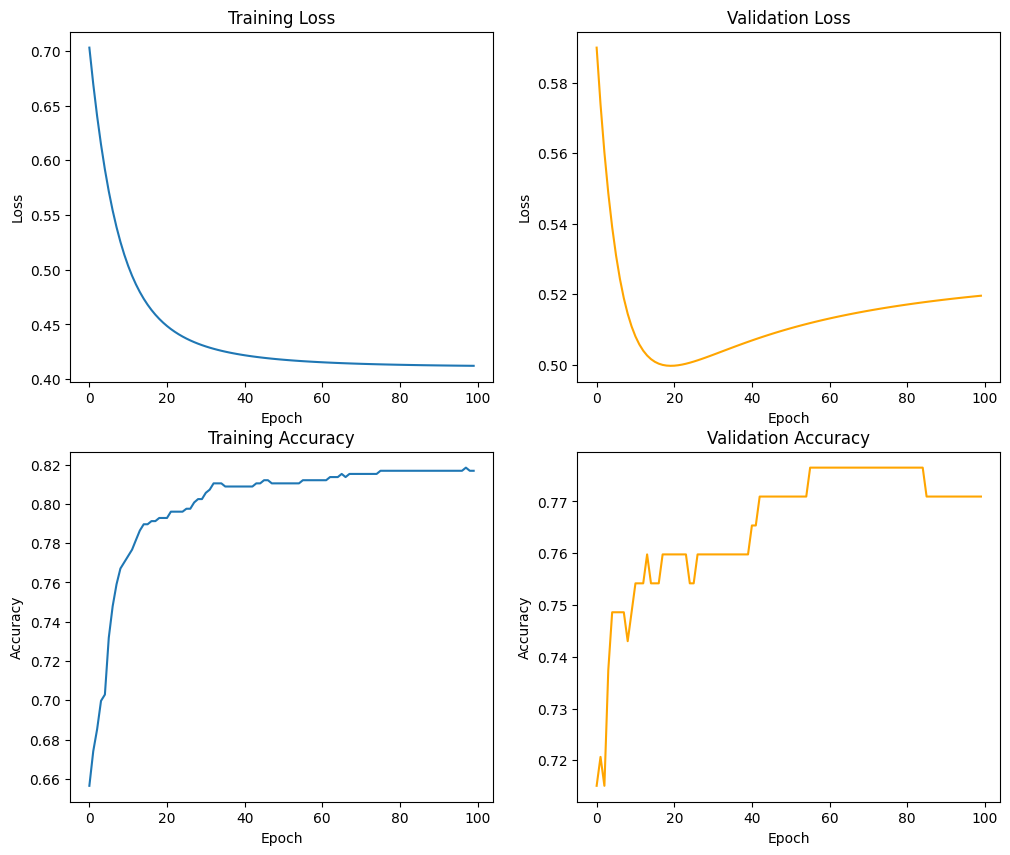

In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Đọc file CSV và thiết lập cột 'PassengerId' làm index
dataset_path = '/content/titanic_modified_dataset.csv'
df = pd.read_csv(dataset_path, index_col='PassengerId')

# Tách biến X và y
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

# Thêm bias vào X
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

# Chia tập dữ liệu thành train, val, test với tỉ lệ 7:2:1
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y, test_size=val_size, random_state=random_state, shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle
)

# Chuẩn hóa dữ liệu (bỏ qua cột bias)
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

# Định nghĩa các hàm cần thiết
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(X, theta):
    dot_product = np.dot(X, theta)
    y_hat = sigmoid(dot_product)
    return y_hat

def compute_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)
    return (-y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)).mean()

def compute_gradient(X, y, y_hat):
    return np.dot(X.T, (y_hat - y)) / y.size

def update_theta(theta, gradient, lr):
    return theta - lr * gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    return (y_hat == y).mean()

# Khai báo các siêu tham số và khởi tạo weights
lr = 0.01
epochs = 100
batch_size = 16

np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])

# Huấn luyện mô hình
train_accs, train_losses = [], []
val_accs, val_losses = [], []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i + batch_size]
        y_i = y_train[i:i + batch_size]

        # Tính y_hat và loss cho tập huấn luyện
        y_hat = predict(X_i, theta)
        train_loss = compute_loss(y_hat, y_i)
        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        train_batch_losses.append(train_loss)
        train_batch_accs.append(compute_accuracy(X_i, y_i, theta))

    # Đánh giá trên tập xác thực
    y_val_hat = predict(X_val, theta)
    val_loss = compute_loss(y_val_hat, y_val)
    val_acc = compute_accuracy(X_val, y_val, theta)

    train_losses.append(np.mean(train_batch_losses))
    val_losses.append(val_loss)
    train_accs.append(np.mean(train_batch_accs))
    val_accs.append(val_acc)

    print(f'EPOCH {epoch + 1}:\tTraining loss: {train_losses[-1]:.3f}\tValidation loss: {val_losses[-1]:.3f}')

# Đánh giá mô hình trên tập kiểm tra
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on validation and test set:')
print(f'Validation Accuracy: {val_set_acc:.2f}')
print(f'Test Accuracy: {test_set_acc:.2f}')

# Trực quan hóa kết quả huấn luyện
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


EPOCH 1:	Training loss: 0.711	Validation loss: 0.682
EPOCH 2:	Training loss: 0.664	Validation loss: 0.640
EPOCH 3:	Training loss: 0.627	Validation loss: 0.606
EPOCH 4:	Training loss: 0.595	Validation loss: 0.578
EPOCH 5:	Training loss: 0.570	Validation loss: 0.555
EPOCH 6:	Training loss: 0.548	Validation loss: 0.535
EPOCH 7:	Training loss: 0.530	Validation loss: 0.519
EPOCH 8:	Training loss: 0.515	Validation loss: 0.505
EPOCH 9:	Training loss: 0.502	Validation loss: 0.493
EPOCH 10:	Training loss: 0.491	Validation loss: 0.483
EPOCH 11:	Training loss: 0.482	Validation loss: 0.475
EPOCH 12:	Training loss: 0.474	Validation loss: 0.467
EPOCH 13:	Training loss: 0.467	Validation loss: 0.461
EPOCH 14:	Training loss: 0.461	Validation loss: 0.455
EPOCH 15:	Training loss: 0.456	Validation loss: 0.450
EPOCH 16:	Training loss: 0.451	Validation loss: 0.445
EPOCH 17:	Training loss: 0.447	Validation loss: 0.441
EPOCH 18:	Training loss: 0.443	Validation loss: 0.438
EPOCH 19:	Training loss: 0.439	Valida

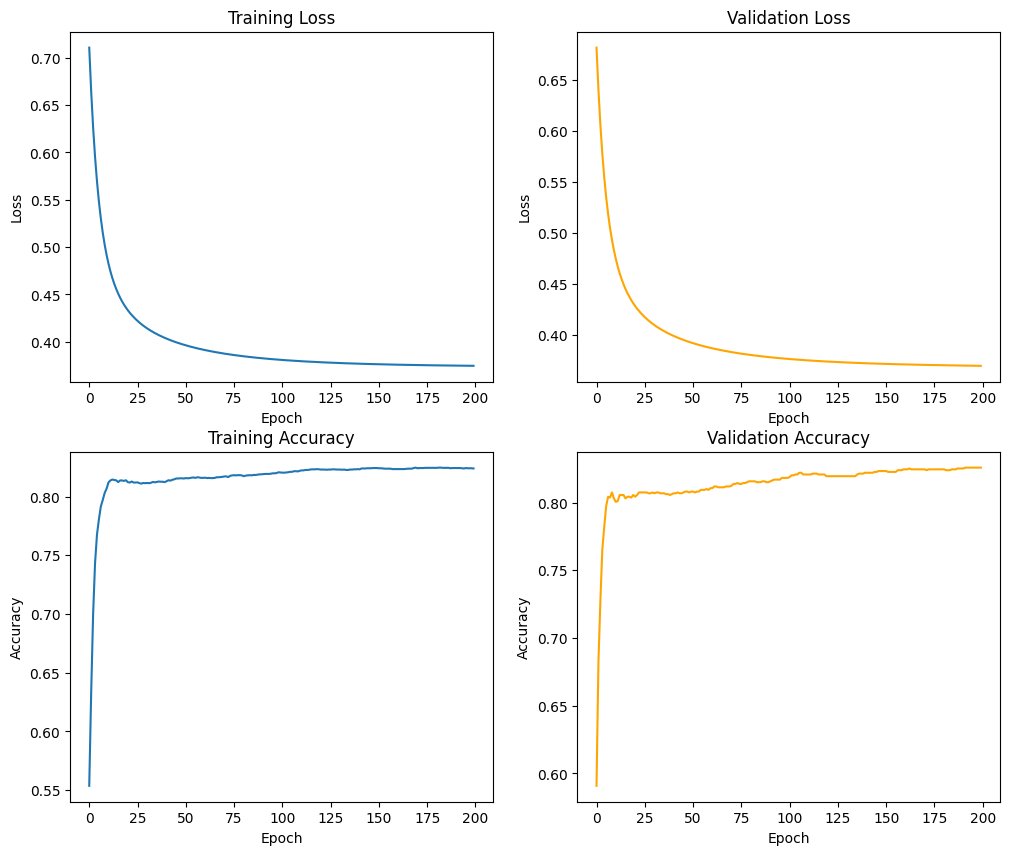

In [3]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nltk.tokenize import TweetTokenizer
from collections import defaultdict

# Khởi tạo tokenizer
nltk.download('punkt')
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

# Định nghĩa hàm chuẩn hóa văn bản
def text_normalize(text):
    text = re.sub(r'^RT[\s]+', '', text)           # Loại bỏ "RT"
    text = re.sub(r'https?://[^\s]+', '', text)     # Loại bỏ các link
    text = re.sub(r'#', '', text)                   # Loại bỏ hashtag
    text = re.sub(r'[^\w\s]', '', text)             # Loại bỏ dấu câu
    return tokenizer.tokenize(text)

# Định nghĩa hàm lấy tần suất xuất hiện của các từ
def get_freqs(df):
    freqs = defaultdict(lambda: 0)
    for _, row in df.iterrows():
        tweet = row['tweet']
        label = row['label']
        tokens = text_normalize(tweet)
        for token in tokens:
            pair = (token, label)
            freqs[pair] += 1
    return freqs

# Định nghĩa hàm tạo vector đặc trưng
def get_feature(text, freqs):
    tokens = text_normalize(text)
    X = np.zeros(3)
    X[0] = 1  # Intercept
    for token in tokens:
        X[1] += freqs.get((token, 0), 0)
        X[2] += freqs.get((token, 1), 0)
    return X

# Đọc file CSV và chuẩn bị dữ liệu
dataset_path = '/content/sentiment_analysis.csv'
df = pd.read_csv(dataset_path, index_col='id')
freqs = get_freqs(df)

# Trích xuất đặc trưng từ dữ liệu
X = np.array([get_feature(tweet, freqs) for tweet in df['tweet']])
y = np.array(df['label'])

# Chia tập dữ liệu thành train, val, test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=val_size, random_state=random_state, shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle
)

# Chuẩn hóa dữ liệu (bỏ qua cột bias)
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

# Định nghĩa các hàm quan trọng cho Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict(X, theta):
    dot_product = np.dot(X, theta)
    y_hat = sigmoid(dot_product)
    return y_hat

def compute_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)
    return (-y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)).mean()

def compute_gradient(X, y, y_hat):
    return np.dot(X.T, (y_hat - y)) / y.size

def update_theta(theta, gradient, lr):
    return theta - lr * gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    return (y_hat == y).mean()

# Khai báo các siêu tham số và khởi tạo weights
lr = 0.01
epochs = 200
batch_size = 128

np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])

# Huấn luyện mô hình
train_accs, train_losses = [], []
val_accs, val_losses = [], []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i + batch_size]
        y_i = y_train[i:i + batch_size]

        # Tính y_hat và loss cho tập huấn luyện
        y_hat = predict(X_i, theta)
        train_loss = compute_loss(y_hat, y_i)
        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        train_batch_losses.append(train_loss)
        train_batch_accs.append(compute_accuracy(X_i, y_i, theta))

    # Đánh giá trên tập xác thực
    y_val_hat = predict(X_val, theta)
    val_loss = compute_loss(y_val_hat, y_val)
    val_acc = compute_accuracy(X_val, y_val, theta)

    train_losses.append(np.mean(train_batch_losses))
    val_losses.append(val_loss)
    train_accs.append(np.mean(train_batch_accs))
    val_accs.append(val_acc)

    print(f'EPOCH {epoch + 1}:\tTraining loss: {train_losses[-1]:.3f}\tValidation loss: {val_losses[-1]:.3f}')

# Đánh giá mô hình trên tập kiểm tra
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on validation and test set:')
print(f'Validation Accuracy: {val_set_acc:.2f}')
print(f'Test Accuracy: {test_set_acc:.2f}')

# Trực quan hóa kết quả huấn luyện
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()
